SHAP available ✅

  1. LOADING DATA
Raw shape : (9754, 51)
  id             airline origin_code destination_code    route aircraft_type  \
0  1  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
1  2  SriLankan Airlines         CMB              BOM  CMB_BOM          A332   
2  3  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
3  4  SriLankan Airlines         CMB              BOM  CMB_BOM          A20N   
4  5  SriLankan Airlines         CMB              BOM  CMB_BOM          A320   

  scheduled_departure_time actual_departure_time scheduled_arrival_time  \
0          12/1/2025 23:40        12/2/2025 1:44         12/2/2025 2:10   
1         11/30/2025 23:40        12/1/2025 2:04         12/1/2025 2:10   
2          11/30/2025 8:28       11/30/2025 8:28       11/30/2025 10:28   
3         11/29/2025 23:40                     0        11/30/2025 2:10   
4         11/28/2025 23:40                     0        11/29/2025 2:10   

  actual_

  0%|          | 0/10 [00:00<?, ?it/s]


Best CV ROC AUC : 0.8854
Best parameters :
  learning_rate: 0.017873564613001217
  num_leaves: 287
  max_depth: 12
  min_child_samples: 62
  feature_fraction: 0.4936111842654619
  bagging_fraction: 0.49359671220172163
  bagging_freq: 1
  lambda_l1: 2.1423021757741068
  lambda_l2: 0.10129197956845731
  min_split_gain: 0.7080725777960455
  min_data_in_leaf: 5
  max_bin: 501
  path_smooth: 0.8324426408004217
Optuna plot note: plot_optimization_history() got an unexpected keyword argument 'ax'

  11. TRAINING FINAL MODEL
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.690747
[200]	valid_0's auc: 0.691945
Early stopping, best iteration is:
[151]	valid_0's auc: 0.693635

Best iteration : 151
Best valid AUC : 0.6936

  12. THRESHOLD TUNING
Default (0.50) → F1: 0.5385
Tuned  (0.3487) → F1: 0.5690


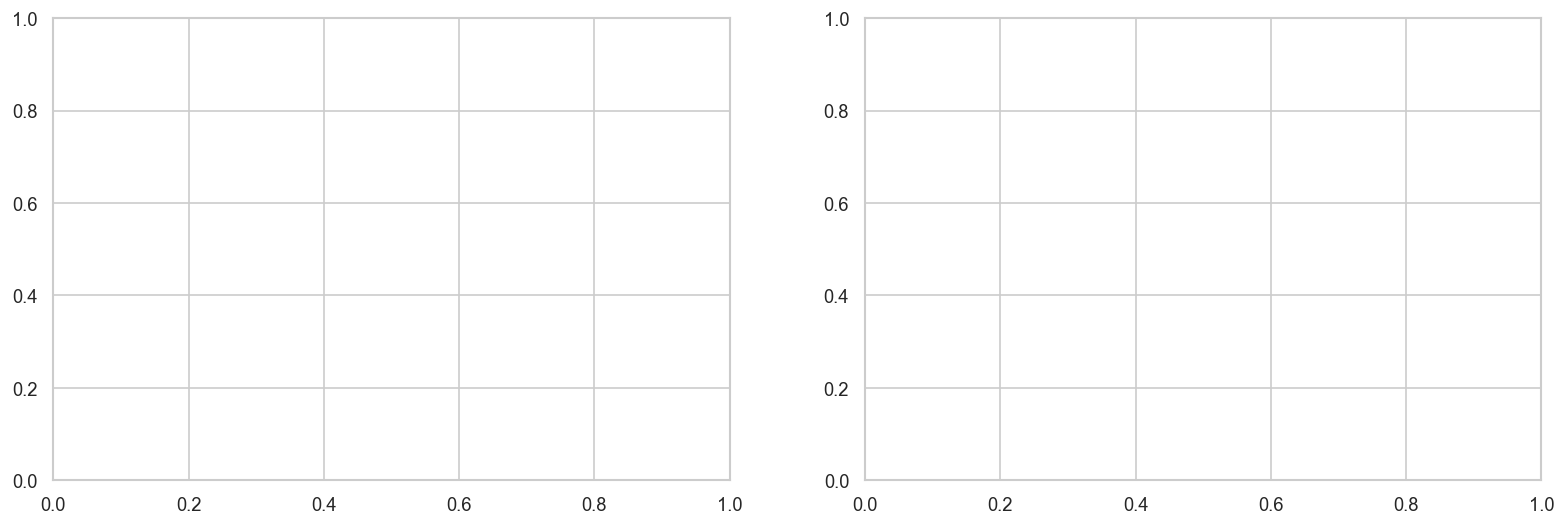

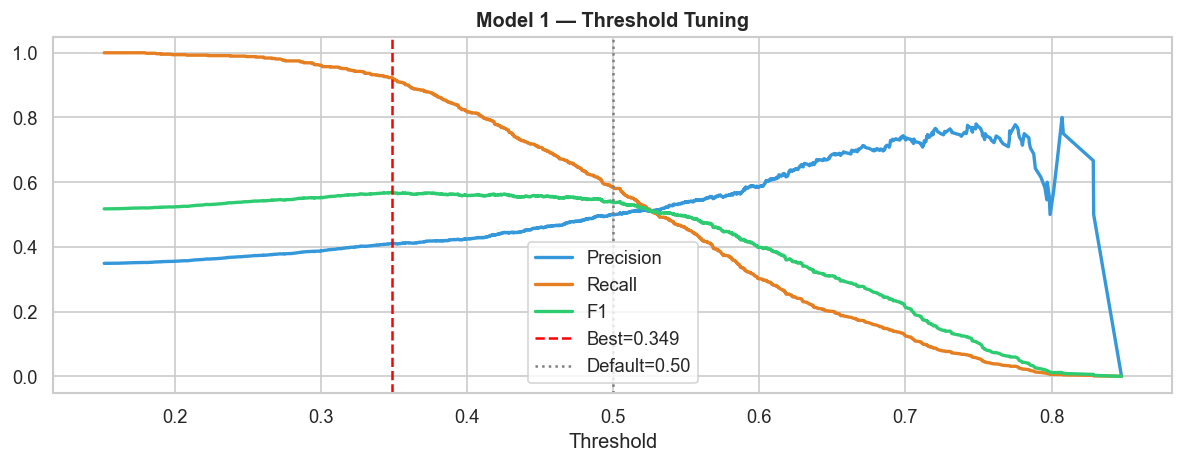


  13. EVALUATION

  Default Threshold (0.50)
  Accuracy    : 0.6509
  ROC AUC     : 0.6936
  F1 Macro    : 0.6289
  F1 Weighted : 0.6561
  Precision   : 0.5000
  Recall      : 0.5835

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.75      0.69      0.72      1262
     Delayed       0.50      0.58      0.54       677

    accuracy                           0.65      1939
   macro avg       0.63      0.64      0.63      1939
weighted avg       0.67      0.65      0.66      1939


  Tuned Threshold (0.3487)
  Accuracy    : 0.5116
  ROC AUC     : 0.6936
  F1 Macro    : 0.5028
  F1 Weighted : 0.4828
  Precision   : 0.4112
  Recall      : 0.9232

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.88      0.29      0.44      1262
     Delayed       0.41      0.92      0.57       677

    accuracy                           0.51      1939
   macro avg       0.64      0.61      0.50      1939
wei

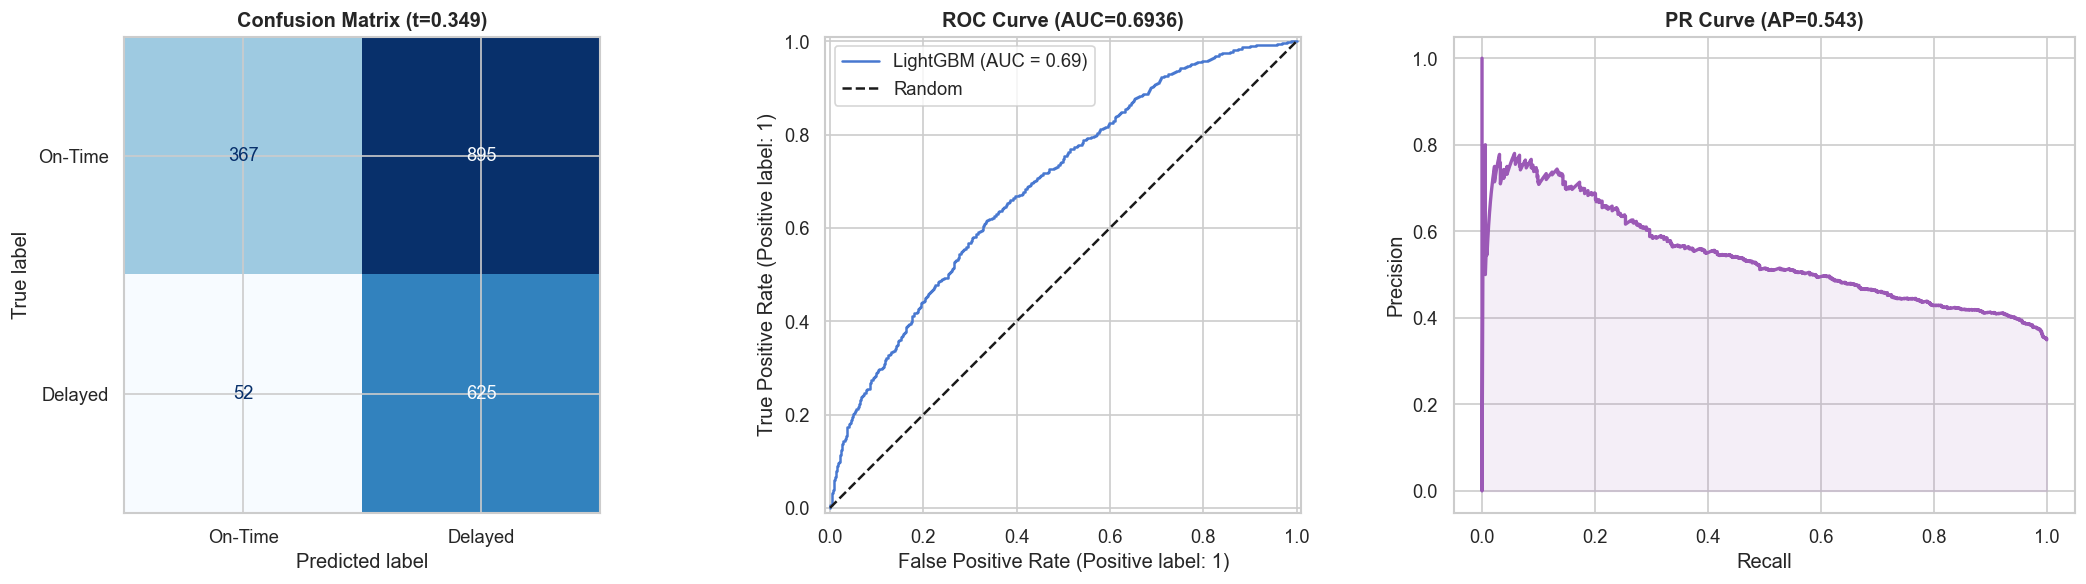

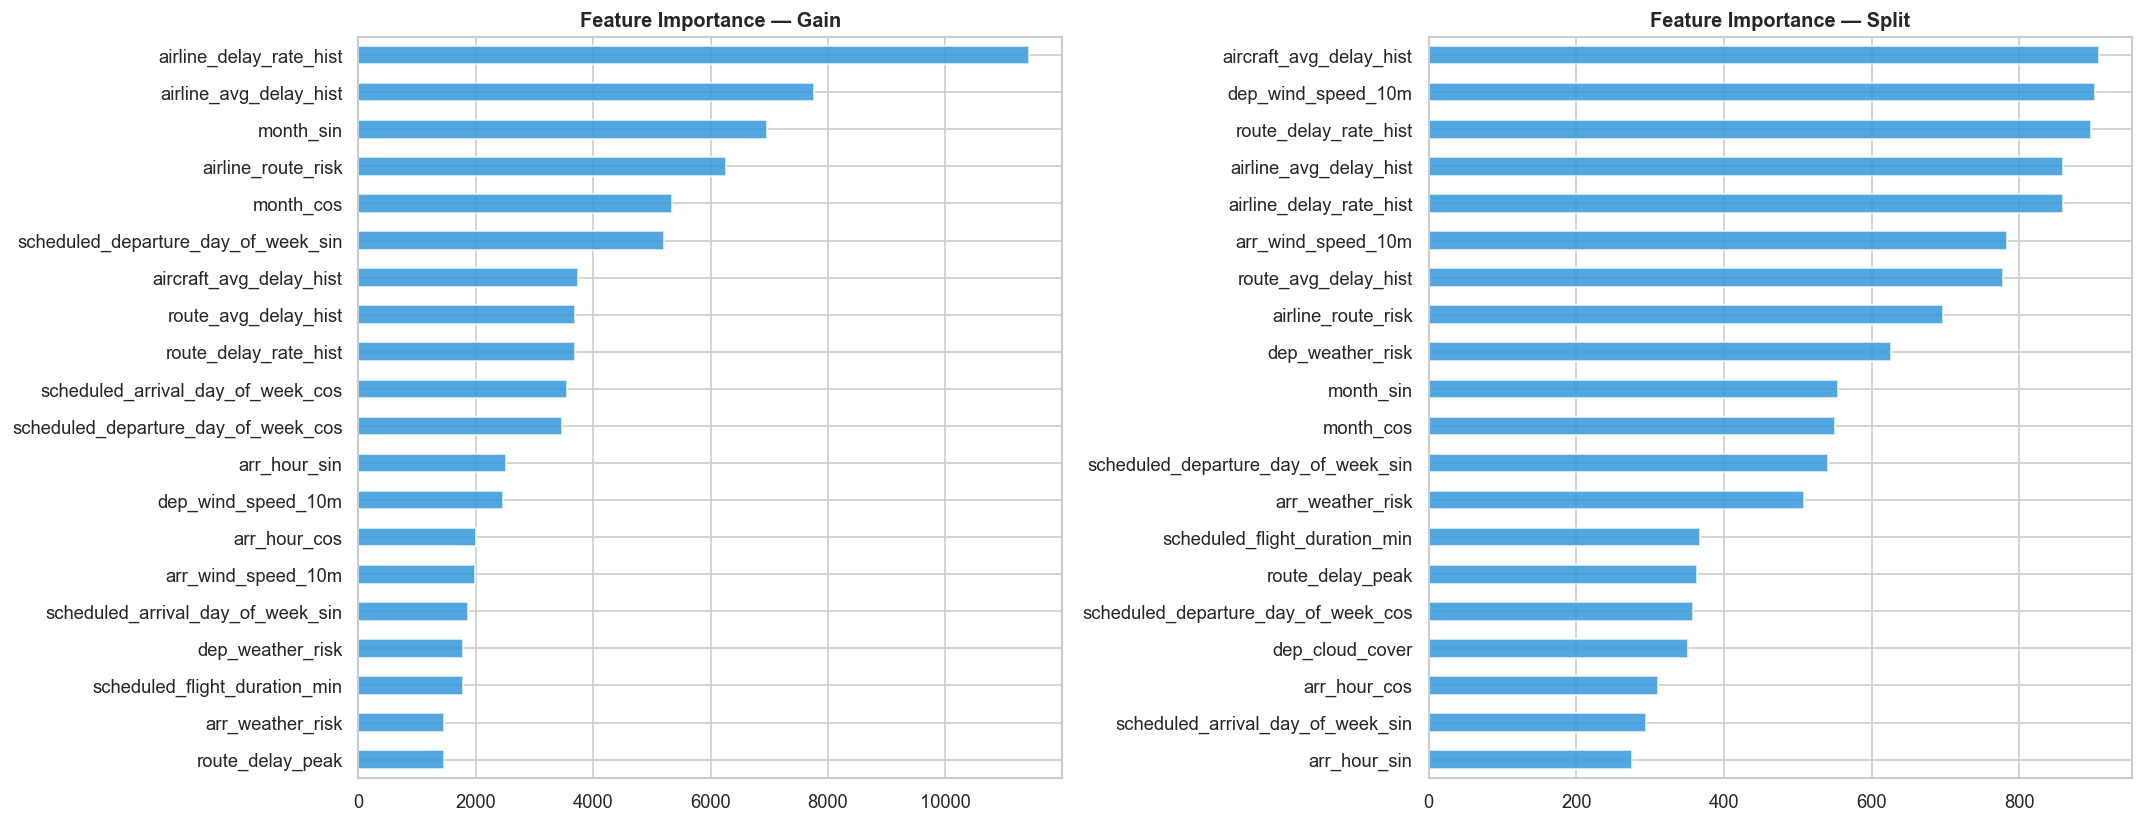


  14. SHAP EXPLAINABILITY


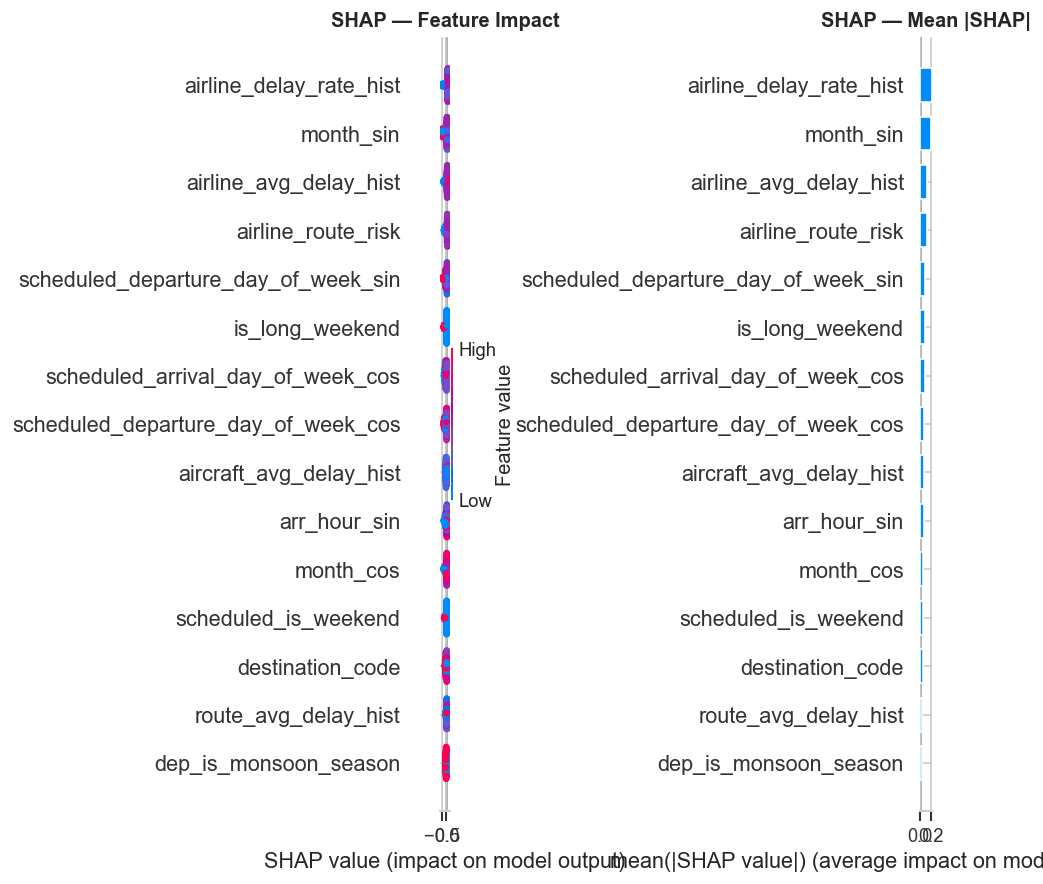


Top 10 features by SHAP:
                            feature  mean_shap
            airline_delay_rate_hist   0.208513
                          month_sin   0.193103
             airline_avg_delay_hist   0.123264
                 airline_route_risk   0.119875
scheduled_departure_day_of_week_sin   0.098061
                    is_long_weekend   0.089958
  scheduled_arrival_day_of_week_cos   0.084604
scheduled_departure_day_of_week_cos   0.071436
            aircraft_avg_delay_hist   0.070123
                       arr_hour_sin   0.065794

  15. SAVING MODEL


In [1]:
"""
Flight Departure Delay Prediction — Model 1 Binary Classifier (Corrected)
==========================================================================
Fixes applied vs user's original code:
  1. feature_engineering() called on cleaned df — not raw train
  2. delay_ratio added to drop_cols (leakage)
  3. Historical averages replaced with time-aware rolling averages (no leakage)
  4. GPU removed — works on any machine
  5. OPTUNA_TRIALS variable used consistently (80 trials)
  6. drop_cols passed into feature_engineering as parameter (no scoping bug)
  7. Time-based train/valid split — realistic deployment scenario
  8. is_unbalance removed from Model 1 (SMOTE already handles it)
  9. Expanded Optuna search space: min_data_in_leaf, max_bin, path_smooth
 10. lgb.cv() used inside Optuna — tighter integration than cross_val_score
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import warnings
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score,
    precision_recall_curve, RocCurveDisplay, average_precision_score
)
from imblearn.over_sampling import SMOTE

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP available ✅")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP not installed — run: pip install shap")

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
OPTUNA_TRIALS = 10       # set to 150 for best results (takes longer)
CV_FOLDS      = 5
EARLY_STOP    = 100
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  1. LOADING DATA")
print("="*60)

train = pd.read_csv("flight_dataset_v2.csv")
print(f"Raw shape : {train.shape}")
print(train.head())
print(train.info())
print(train.describe())

# ═══════════════════════════════════════════════════════════════════════════════
# 2. CLEAN — REMOVE CANCELLED & DIVERTED
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  2. CLEANING")
print("="*60)

print(f"Cancelled : {train['is_cancelled'].sum()} rows removed")
print(f"Diverted  : {train['is_diverted'].sum()} rows removed")

df = train[
    (train['is_cancelled'] == 0) &
    (train['is_diverted']  == 0)
].copy()

# Clip negative delays — early departures treated as on-time
df['departure_delay_min'] = df['departure_delay_min'].clip(lower=0)

# ── CRITICAL: sort by date for time-based split & rolling averages ─────────────
# Parse scheduled_departure_time if it exists as a string
if df['scheduled_departure_time'].dtype == object:
    df['scheduled_departure_time'] = pd.to_datetime(
        df['scheduled_departure_time'], dayfirst=True, errors='coerce'
    )
df = df.sort_values('scheduled_departure_time').reset_index(drop=True)

print(f"Clean shape : {df.shape}")
print(f"Date range  : {df['scheduled_departure_time'].min()} → {df['scheduled_departure_time'].max()}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. TIME-AWARE HISTORICAL FEATURES (NO LEAKAGE)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  3. TIME-AWARE HISTORICAL FEATURES")
print("="*60)
"""
Each flight only sees the average delay of flights that happened
BEFORE it on the same route / airline / aircraft type.

This replaces the original route_avg_delay etc. which were computed
from the full dataset — that is data leakage.
"""

global_avg_delay  = df['departure_delay_min'].mean()
global_delay_rate = (df['departure_delay_min'] >= 15).mean()

# Route historical average delay
df['route_avg_delay_hist'] = (
    df.groupby('route')['departure_delay_min']
    .transform(lambda x: x.shift(1).expanding().mean())
    .fillna(global_avg_delay)
)

# Route historical delay rate
df['route_delay_rate_hist'] = (
    df.groupby('route')['departure_delay_min']
    .transform(lambda x: (x.shift(1) >= 15).expanding().mean())
    .fillna(global_delay_rate)
)

# Airline historical average delay
df['airline_avg_delay_hist'] = (
    df.groupby('airline')['departure_delay_min']
    .transform(lambda x: x.shift(1).expanding().mean())
    .fillna(global_avg_delay)
)

# Airline historical delay rate
df['airline_delay_rate_hist'] = (
    df.groupby('airline')['departure_delay_min']
    .transform(lambda x: (x.shift(1) >= 15).expanding().mean())
    .fillna(global_delay_rate)
)

# Aircraft type historical average delay
df['aircraft_avg_delay_hist'] = (
    df.groupby('aircraft_type')['departure_delay_min']
    .transform(lambda x: x.shift(1).expanding().mean())
    .fillna(global_avg_delay)
)

print("Historical features computed ✅ (no leakage — each row uses only past data)")
print(f"  route_avg_delay_hist   mean = {df['route_avg_delay_hist'].mean():.2f}")
print(f"  airline_avg_delay_hist mean = {df['airline_avg_delay_hist'].mean():.2f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. CREATE TARGET
# ═══════════════════════════════════════════════════════════════════════════════
df['binary_delay_dep'] = (df['departure_delay_min'] >= 15).astype(int)
print(f"\nTarget: binary_delay_dep")
print(f"  On-Time (0): {(df['binary_delay_dep']==0).sum():,}")
print(f"  Delayed (1): {(df['binary_delay_dep']==1).sum():,}")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. DEFINE COLUMNS TO DROP
# ═══════════════════════════════════════════════════════════════════════════════
# All leakage columns, identifiers, and originals replaced by _hist versions
DROP_COLS = [
    # Identifiers
    'id',
    'dep_date_only',
    # Actual times — unknown before departure
    'actual_departure_time',
    'actual_arrival_time',
    # Scheduled times — captured by hour/day/month features
    'scheduled_departure_time',
    'scheduled_arrival_time',
    # Direct leakage — all derived FROM the delay
    'departure_delay_min',
    'arrival_delay_min',
    'delay_ratio',              # FIX 2 — was missing in original
    'binary_delay_arr',
    'delay_class_dep',
    'delay_class_arr',
    # Original same-dataset averages — replaced by _hist versions above
    'route_avg_delay',          # FIX 3 — now properly dropped
    'route_delay_rate',
    'airline_avg_delay',
    'airline_delay_rate',
    'aircraft_avg_delay',
    # Unknown before departure
    'is_diverted',
    'is_cancelled',
    # Zero variance (all CMB)
    'origin_code',
    # Redundant — 100m correlated with 10m
    'dep_wind_speed_100m',
    'arr_wind_speed_100m',
]

# ═══════════════════════════════════════════════════════════════════════════════
# 6. FEATURE ENGINEERING
# FIX 6 — drop_cols passed as parameter, not relied on via scoping
# FIX 1 — called on cleaned df, not raw train
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  6. FEATURE ENGINEERING")
print("="*60)

def feature_engineering(df, drop_cols):
    """
    Build all features. Operates on a copy.
    drop_cols passed explicitly — no hidden scoping dependency.
    """
    df = df.copy()

    # Drop leakage & irrelevant columns
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # ── Cyclical hour encoding ─────────────────────────────────────────────────
    for col, prefix in [
        ('scheduled_departure_hour', 'dep'),
        ('scheduled_arrival_hour',   'arr')
    ]:
        if col in df.columns:
            df[f'{prefix}_hour_sin'] = np.sin(2 * np.pi * df[col] / 24)
            df[f'{prefix}_hour_cos'] = np.cos(2 * np.pi * df[col] / 24)

    # ── Cyclical month encoding ────────────────────────────────────────────────
    if 'scheduled_month' in df.columns:
        df['month_sin'] = np.sin(2 * np.pi * df['scheduled_month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['scheduled_month'] / 12)

    # ── Day of week: string → int → cyclical ──────────────────────────────────
    day_map = {
        'Monday':0, 'Tuesday':1, 'Wednesday':2,
        'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6
    }
    for col in ['scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week']:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].map(day_map)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / 7)
            df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / 7)

    # ── Weather composite features ─────────────────────────────────────────────
    if all(c in df.columns for c in ['dep_precipitation', 'arr_precipitation']):
        df['total_precipitation'] = df['dep_precipitation'] + df['arr_precipitation']
        df['any_precipitation']   = (
            (df['dep_precipitation'] > 0) | (df['arr_precipitation'] > 0)
        ).astype(int)

    if all(c in df.columns for c in ['dep_precipitation', 'dep_cloud_cover', 'dep_visibility']):
        df['dep_weather_risk'] = (
            df['dep_precipitation'] +
            df['dep_cloud_cover'] / 100 -
            df['dep_visibility'] / 50000
        )

    if all(c in df.columns for c in ['arr_precipitation', 'arr_cloud_cover', 'arr_visibility']):
        df['arr_weather_risk'] = (
            df['arr_precipitation'] +
            df['arr_cloud_cover'] / 100 -
            df['arr_visibility'] / 50000
        )

    # ── Low visibility flags ───────────────────────────────────────────────────
    if 'dep_visibility' in df.columns:
        df['low_visibility_dep'] = (df['dep_visibility'] < 5000).astype(int)
    if 'arr_visibility' in df.columns:
        df['low_visibility_arr'] = (df['arr_visibility'] < 5000).astype(int)

    # ── Interaction features ───────────────────────────────────────────────────
    if all(c in df.columns for c in ['scheduled_late_night_departure', 'dep_is_monsoon_season']):
        df['night_monsoon'] = (
            df['scheduled_late_night_departure'] * df['dep_is_monsoon_season']
        )

    if all(c in df.columns for c in ['scheduled_late_night_departure', 'route_delay_rate_hist']):
        df['night_high_route_risk'] = (
            df['scheduled_late_night_departure'] * df['route_delay_rate_hist']
        )

    if all(c in df.columns for c in ['dep_is_monsoon_season', 'dep_precipitation']):
        df['monsoon_precip_risk'] = (
            df['dep_is_monsoon_season'] * np.log1p(df['dep_precipitation'])
        )

    if all(c in df.columns for c in ['scheduled_is_weekend', 'scheduled_is_peak_hour']):
        df['weekend_peak'] = df['scheduled_is_weekend'] * df['scheduled_is_peak_hour']

    if all(c in df.columns for c in ['airline_delay_rate_hist', 'route_delay_rate_hist']):
        df['airline_route_risk'] = (
            df['airline_delay_rate_hist'] * df['route_delay_rate_hist']
        )

    if all(c in df.columns for c in ['route_avg_delay_hist', 'scheduled_is_peak_hour']):
        df['route_delay_peak'] = (
            df['route_avg_delay_hist'] * df['scheduled_is_peak_hour']
        )

    if 'scheduled_month' in df.columns:
        df['is_peak_month'] = df['scheduled_month'].isin([1, 4, 7, 8, 12]).astype(int)

    return df


# FIX 1 — pass cleaned df, not raw train
# FIX 6 — pass DROP_COLS explicitly
df_feat = feature_engineering(df, DROP_COLS)

print(f"Feature matrix shape : {df_feat.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. SEPARATE FEATURES & TARGET
# ═══════════════════════════════════════════════════════════════════════════════
TARGET = 'binary_delay_dep'

X_all    = df_feat.drop(columns=[TARGET])
y_all    = df_feat[TARGET]

# ── Label encode categoricals ──────────────────────────────────────────────────
CAT_FEATURES = ['airline', 'aircraft_type', 'destination_code', 'route']
le_dict = {}
for col in CAT_FEATURES:
    if col in X_all.columns:
        le = LabelEncoder()
        X_all[col] = le.fit_transform(X_all[col].astype(str))
        le_dict[col] = le

# Drop remaining datetime / object columns
bad_cols = X_all.select_dtypes(include=['datetime64', 'object']).columns.tolist()
if bad_cols:
    print(f"Dropping non-numeric: {bad_cols}")
    X_all = X_all.drop(columns=bad_cols)

print(f"\nFeature matrix : {X_all.shape}")
print(f"Target         : {dict(y_all.value_counts().sort_index())}")
print(f"Class balance  : {y_all.value_counts()[0] / y_all.value_counts()[1]:.2f}:1")
print(f"\nAll features used:")
for c in X_all.columns:
    print(f"  {c}")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. TIME-BASED TRAIN/VALIDATION SPLIT
# FIX 7 — last 20% of dates = validation (not random)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  8. TIME-BASED SPLIT")
print("="*60)

split_idx = int(len(X_all) * (1 - TEST_SIZE))

X_train = X_all.iloc[:split_idx].copy()
X_valid = X_all.iloc[split_idx:].copy()
y_train = y_all.iloc[:split_idx].copy()
y_valid = y_all.iloc[split_idx:].copy()

print(f"Train : {X_train.shape} (rows 0 – {split_idx-1})")
print(f"Valid : {X_valid.shape} (rows {split_idx} – {len(X_all)-1})")
print(f"Train class dist : {dict(y_train.value_counts().sort_index())}")
print(f"Valid class dist : {dict(y_valid.value_counts().sort_index())}")

# ═══════════════════════════════════════════════════════════════════════════════
# 9. SMOTE — TRAINING SET ONLY
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  9. SMOTE (training only)")
print("="*60)

sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_res = pd.Series(y_train_res)

print(f"Before SMOTE : {dict(y_train.value_counts().sort_index())}")
print(f"After  SMOTE : {dict(y_train_res.value_counts().sort_index())}")

# ═══════════════════════════════════════════════════════════════════════════════
# 10. OPTUNA HYPERPARAMETER TUNING
# FIX 4 — OPTUNA_TRIALS variable used consistently
# FIX 5 — GPU removed
# FIX 9 — expanded search space
# FIX 10 — lgb.cv() for tighter integration
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print(f"  10. OPTUNA TUNING ({OPTUNA_TRIALS} trials)")
print("="*60)

def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'boosting_type':     'gbdt',
        'verbosity':         -1,
        'seed':              RANDOM_STATE,
        # Core
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        # Sampling
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
        # Regularisation
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
        # FIX 9 — new params added to search
        'min_data_in_leaf':  trial.suggest_int('min_data_in_leaf', 5, 50),
        'max_bin':           trial.suggest_int('max_bin', 128, 512),
        'path_smooth':       trial.suggest_float('path_smooth', 0.0, 1.0),
    }

    dtrain_cv = lgb.Dataset(X_train_res, label=y_train_res)

    # FIX 10 — use lgb.cv() directly (more reliable than sklearn cross_val_score)
    cv_result = lgb.cv(
        params,
        dtrain_cv,
        num_boost_round=1000,
        nfold=CV_FOLDS,
        stratified=True,
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0)
        ],
        seed=RANDOM_STATE
    )

    return max(cv_result['valid auc-mean'])


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nBest CV ROC AUC : {study.best_value:.4f}")
print("Best parameters :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ─ Optuna visualisation ────────────────────────────────────────────────────────
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    optuna.visualization.matplotlib.plot_optimization_history(study, ax=axes[0])
    axes[0].set_title('Optuna Optimization History', fontweight='bold')
    optuna.visualization.matplotlib.plot_param_importances(study, ax=axes[1])
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Optuna plot note: {e}")

# ═══════════════════════════════════════════════════════════════════════════════
# 11. TRAIN FINAL MODEL WITH EARLY STOPPING
# FIX 5 — no 'device': 'gpu'
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  11. TRAINING FINAL MODEL")
print("="*60)

best_params = study.best_params.copy()
best_params.update({
    'objective':     'binary',
    'metric':        'auc',
    'boosting_type': 'gbdt',
    'verbosity':     -1,
    'seed':          RANDOM_STATE,
    # FIX 5: 'device': 'gpu' intentionally removed — works on any machine
})

dtrain_final = lgb.Dataset(X_train_res, label=y_train_res)
dvalid_final = lgb.Dataset(X_valid,     label=y_valid, reference=dtrain_final)

final_model = lgb.train(
    best_params,
    dtrain_final,
    num_boost_round=3000,          # ceiling — early stopping controls actual count
    valid_sets=[dvalid_final],
    callbacks=[
        lgb.early_stopping(EARLY_STOP, verbose=True),
        lgb.log_evaluation(100)
    ]
)

best_iter = final_model.best_iteration
print(f"\nBest iteration : {best_iter}")
print(f"Best valid AUC : {final_model.best_score['valid_0']['auc']:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 12. THRESHOLD TUNING
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  12. THRESHOLD TUNING")
print("="*60)

val_probs = final_model.predict(X_valid, num_iteration=best_iter)

precisions, recalls, thresholds = precision_recall_curve(y_valid, val_probs)
f1s        = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx   = np.argmax(f1s)
best_thresh = thresholds[best_idx]

print(f"Default (0.50) → F1: {f1_score(y_valid, (val_probs >= 0.50).astype(int)):.4f}")
print(f"Tuned  ({best_thresh:.4f}) → F1: {f1s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', lw=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#e67e22', lw=2)
ax.plot(thresholds, f1s,             label='F1',        color='#2ecc71', lw=2)
ax.axvline(best_thresh, color='red',  linestyle='--', lw=1.5, label=f'Best={best_thresh:.3f}')
ax.axvline(0.50,        color='gray', linestyle=':',  lw=1.5, label='Default=0.50')
ax.set_xlabel('Threshold')
ax.set_title('Model 1 — Threshold Tuning', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

val_preds_default = (val_probs >= 0.50).astype(int)
val_preds_tuned   = (val_probs >= best_thresh).astype(int)

# ═══════════════════════════════════════════════════════════════════════════════
# 13. EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  13. EVALUATION")
print("="*60)

def print_metrics(y_true, y_pred, y_prob, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy    : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  ROC AUC     : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  F1 Macro    : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  F1 Weighted : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Precision   : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall      : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['On-Time', 'Delayed']))


print_metrics(y_valid, val_preds_default, val_probs, "Default Threshold (0.50)")
print_metrics(y_valid, val_preds_tuned,   val_probs, f"Tuned Threshold ({best_thresh:.4f})")

# ─ Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_valid, val_preds_tuned),
    display_labels=['On-Time', 'Delayed']
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix (t={best_thresh:.3f})', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_valid, val_probs, ax=axes[1], name='LightGBM')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y_valid, val_probs):.4f})', fontweight='bold')
axes[1].legend()

# PR curve
ap = average_precision_score(y_valid, val_probs)
p_pr, r_pr, _ = precision_recall_curve(y_valid, val_probs)
axes[2].plot(r_pr, p_pr, color='#9b59b6', lw=2)
axes[2].fill_between(r_pr, p_pr, alpha=0.1, color='#9b59b6')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title(f'PR Curve (AP={ap:.3f})', fontweight='bold')

plt.tight_layout(); plt.show()

# ─ Feature importance ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, imp_type in zip(axes, ['gain', 'split']):
    imp = pd.Series(
        final_model.feature_importance(importance_type=imp_type),
        index=X_train_res.columns
    ).sort_values(ascending=False).head(20)
    imp.plot(kind='barh', ax=ax, color='#3498db', alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance — {imp_type.capitalize()}', fontweight='bold')
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 14. SHAP EXPLAINABILITY
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  14. SHAP EXPLAINABILITY")
print("="*60)

if SHAP_AVAILABLE:
    explainer  = shap.TreeExplainer(final_model)
    sample_idx = np.random.choice(len(X_valid), min(500, len(X_valid)), replace=False)
    X_sample   = X_valid.iloc[sample_idx]
    shap_vals  = explainer.shap_values(X_sample)
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(axes[0])
    shap.summary_plot(sv, X_sample, plot_type='dot', show=False, max_display=15)
    axes[0].set_title('SHAP — Feature Impact', fontweight='bold')
    plt.sca(axes[1])
    shap.summary_plot(sv, X_sample, plot_type='bar', show=False, max_display=15)
    axes[1].set_title('SHAP — Mean |SHAP|', fontweight='bold')
    plt.tight_layout(); plt.show()

    shap_df = pd.DataFrame({
        'feature':   X_valid.columns,
        'mean_shap': np.abs(sv).mean(axis=0)
    }).sort_values('mean_shap', ascending=False)
    print("\nTop 10 features by SHAP:")
    print(shap_df.head(10).to_string(index=False))
else:
    print("Install SHAP for explainability: pip install shap")

# ═══════════════════════════════════════════════════════════════════════════════
# 15. SAVE MODEL
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  15. SAVING MODEL")
print("="*60)

# final_model.save_model('model1_binary_lgbm.txt')

# joblib.dump({
#     'threshold':        best_thresh,
#     'best_iteration':   best_iter,
#     'feature_cols':     list(X_train_res.columns),
#     'label_encoders':   le_dict,
#     'optuna_best_params': study.best_params,
#     'optuna_best_auc':  study.best_value,
#     'split_idx':        split_idx,
# }, 'model1_config.pkl')

# print("Saved:")
# print("  model1_binary_lgbm.txt  — LightGBM booster")
# print("  model1_config.pkl       — threshold, features, encoders")
# print(f"\n  → Use threshold {best_thresh:.4f} at inference time")

# ═══════════════════════════════════════════════════════════════════════════════
# 16. INFERENCE HELPER
# # ═══════════════════════════════════════════════════════════════════════════════
# def predict_delay(X_new_raw):
#     """
#     Predict on new raw flight data.
#     X_new_raw : DataFrame with same columns as original dataset (before feature engineering).
#     """
#     config    = joblib.load('model1_config.pkl')
#     model     = lgb.Booster(model_file='model1_binary_lgbm.txt')
#     threshold = config['threshold']
#     best_iter = config['best_iteration']
#     le_dict   = config['label_encoders']
#     feat_cols = config['feature_cols']

#     X_new = feature_engineering(X_new_raw.copy(), DROP_COLS)
#     for col, le in le_dict.items():
#         if col in X_new.columns:
#             known = set(le.classes_)
#             X_new[col] = X_new[col].astype(str).apply(
#                 lambda x: x if x in known else le.classes_[0]
#             )
#             X_new[col] = le.transform(X_new[col])

#     X_new = X_new[feat_cols]
#     proba = model.predict(X_new, num_iteration=best_iter)
#     preds = (proba >= threshold).astype(int)

#     return pd.DataFrame({
#         'prediction': preds,
#         'label':      ['Delayed' if p == 1 else 'On-Time' for p in preds],
#         'delay_prob': proba.round(4),
#         'confidence': np.where(preds == 1, proba, 1 - proba).round(4)
#     })


# # Quick test on first 5 validation rows
# print("\nSample predictions on first 5 validation rows:")
# sample = predict_delay(df.iloc[split_idx: split_idx + 5])
# print(sample.to_string(index=False))
